# Baseline vs podado (mismo run IMP)

Compara el modelo **denso** al final de la ronda 0 (`round_00/model_state.pt`) con el **final podado** (`model_final.pt`) del mismo directorio de run.

- **Tamaño en disco:** bytes del archivo `.pt`.
- **Huella de tensores:** parámetros + buffers en RAM (misma arquitectura y dtype; la poda es lógica — muchos ceros — no tensores más pequeños).
- **Dispersidad:** `achieved_sparsity` en `imp_index.json` y `weight_sparsity_ratio` con un `eps` fijo (no confundir con `val/weight_sparsity_ratio` del entrenamiento, ligado al L1).
- **Precisión:** `val/acc` registrada en entrenamiento y una pasada completa por **test** CIFAR-10.
- **Velocidad:** latencia media por batch tras warm-up.

Puedes cambiar `BASELINE_CKPT` a otro `model_state.pt` (p. ej. un run solo denso de grid search) si quieres otra definición de baseline.

In [3]:
"""Rutas: repo, datos CIFAR-10 y checkpoints del run IMP."""

from __future__ import annotations

import sys
from pathlib import Path

import torch


def resolve_repo_root() -> Path:
    """Sube desde notebooks/ hasta la raíz del repo (directorio con src/pia)."""
    p = Path.cwd().resolve()
    if (p / "src" / "pia").is_dir():
        return p
    if (p.parent / "src" / "pia").is_dir():
        return p.parent
    msg = f"No se encontró src/pia. cwd={p}"
    raise FileNotFoundError(msg)


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

DATA_ROOT = str(REPO_ROOT / "data")
IMP_RUN_DIR = REPO_ROOT / "runs" / "lt" / "large-checkpoint"
BASELINE_CKPT = IMP_RUN_DIR / "round_00" / "model_state.pt"
PRUNED_CKPT = IMP_RUN_DIR / "model_final.pt"
IMP_INDEX = IMP_RUN_DIR / "imp_index.json"

BATCH_SIZE = 128
MAX_TIMING_BATCHES = 30
SPARSITY_EPS = 1e-6

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("BASELINE_CKPT:", BASELINE_CKPT)
print("PRUNED_CKPT:", PRUNED_CKPT)

REPO_ROOT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia
DATA_ROOT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/data
BASELINE_CKPT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/runs/lt/large-checkpoint/round_00/model_state.pt
PRUNED_CKPT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/runs/lt/large-checkpoint/model_final.pt


In [4]:
"""Imports de pia, utilidades de carga y medición."""

from __future__ import annotations

import json
import statistics
import time
from typing import Any

import torch
from torch import nn

from pia.data.cifar10 import build_cifar10_test_loader
from pia.models.resnet_cifar import apply_he_init, build_resnet18_cifar
from pia.training.metrics import weight_sparsity_ratio


def pick_device() -> torch.device:
    """Elige MPS, CUDA o CPU."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def load_state_dict(path: Path) -> dict[str, torch.Tensor]:
    """Carga un state_dict en CPU (formato guardado por IMP)."""
    try:
        raw = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        raw = torch.load(path, map_location="cpu")
    if not isinstance(raw, dict):
        msg = "Se esperaba un dict (state_dict)."
        raise TypeError(msg)
    return raw


def model_memory_bytes(module: nn.Module) -> tuple[int, int, int]:
    """
    Devuelve bytes de parámetros, bytes de buffers y número de parámetros.

    Cota del almacenamiento de tensores (sin activaciones ni autograd).
    """
    param_b = sum(p.numel() * p.element_size() for p in module.parameters())
    buf_b = sum(b.numel() * b.element_size() for b in module.buffers())
    n_params = sum(p.numel() for p in module.parameters())
    return param_b, buf_b, n_params


def build_resnet_from_checkpoint(sd: dict[str, torch.Tensor]) -> nn.Module:
    """ResNet-18 CIFAR-10 con He init y pesos del checkpoint."""
    model = build_resnet18_cifar(num_classes=10)
    apply_he_init(model)
    model.load_state_dict(sd)
    return model


def eval_test_accuracy(model: nn.Module, loader: Any, device: torch.device) -> float:
    """Accuracy media en todo el test loader (pesos por tamaño de batch)."""
    model.eval()
    model.to(device)
    total_correct = 0
    total_n = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            pred = logits.argmax(dim=1)
            total_correct += int((pred == y).sum().item())
            total_n += int(y.shape[0])
    return total_correct / max(1, total_n)


def time_forward_batches(
    model: nn.Module,
    loader: Any,
    device: torch.device,
    *,
    max_batches: int,
) -> tuple[float, float]:
    """
    Warm-up 1 batch y luego mide latencias; devuelve (media_ms, std_ms).
    """
    model.eval()
    model.to(device)
    it = iter(loader)
    x0, _ = next(it)
    x0 = x0.to(device, non_blocking=True)
    with torch.no_grad():
        _ = model(x0)
    if device.type == "cuda":
        torch.cuda.synchronize()
    lat_ms: list[float] = []
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            if n >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize()
            lat_ms.append((time.perf_counter() - t0) * 1000.0)
            n += 1
    if len(lat_ms) < 2:
        m = float(lat_ms[0]) if lat_ms else 0.0
        return m, 0.0
    return statistics.mean(lat_ms), statistics.stdev(lat_ms)


device = pick_device()
print("device:", device)

device: mps


In [5]:
"""Métricas registradas en entrenamiento (imp_index.json)."""

import pandas as pd

if not IMP_INDEX.is_file():
    raise FileNotFoundError(f"Falta {IMP_INDEX}")

idx = json.loads(IMP_INDEX.read_text(encoding="utf-8"))
rounds = idx.get("rounds", [])
rows_logged: list[dict[str, Any]] = []
for r in rounds:
    fm = r.get("final_metrics", {})
    rows_logged.append(
        {
            "round": r.get("round"),
            "val_acc_logged": fm.get("val/acc"),
            "train_acc_logged": fm.get("train/acc"),
            "achieved_sparsity": r.get("achieved_sparsity"),
        }
    )
df_logged = pd.DataFrame(rows_logged)
display(df_logged)

r0 = rounds[0] if rounds else {}
r_last = rounds[-1] if rounds else {}
print("Ronda 0 val/acc (log):", r0.get("final_metrics", {}).get("val/acc"))
print("Última ronda val/acc (log):", r_last.get("final_metrics", {}).get("val/acc"))
print("Última achieved_sparsity:", r_last.get("achieved_sparsity"))

,round,val_acc_logged,train_acc_logged,achieved_sparsity
0,0,0.854883,0.868282,0.10000
1,1,0.894141,0.918159,0.19000
2,2,0.899609,0.917841,0.27100
3,3,0.890039,0.920341,0.34390
4,4,0.898438,0.918861,0.40951
5,5,0.891211,0.917971,0.40951


Ronda 0 val/acc (log): 0.8548828125
Última ronda val/acc (log): 0.8912109375
Última achieved_sparsity: 0.409509839890394


In [6]:
"""DataLoader de test (misma evaluación para ambos modelos)."""

test_loader = build_cifar10_test_loader(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=0,
)
print("batches test:", len(test_loader))

batches test: 79


/Users/carlosvalerio/Documents/Study/Aprendizaje/pia/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [7]:
"""Carga baseline, mide y libera; luego podado (menor pico de VRAM)."""

import pandas as pd
from IPython.display import display

results: list[dict[str, Any]] = []

for label, ckpt in (("baseline_r00", BASELINE_CKPT), ("pruned_final", PRUNED_CKPT)):
    if not ckpt.is_file():
        raise FileNotFoundError(f"Falta checkpoint: {ckpt}")
    disk_b = ckpt.stat().st_size
    sd = load_state_dict(ckpt)
    model = build_resnet_from_checkpoint(sd)
    del sd
    pb, bb, npar = model_memory_bytes(model)
    ws = weight_sparsity_ratio(model, eps=SPARSITY_EPS)
    test_acc = eval_test_accuracy(model, test_loader, device)
    mean_ms, std_ms = time_forward_batches(
        model, test_loader, device, max_batches=MAX_TIMING_BATCHES
    )
    results.append(
        {
            "modelo": label,
            "checkpoint": str(ckpt.relative_to(REPO_ROOT)),
            "disco_MiB": disk_b / (1024**2),
            "tensores_MiB": (pb + bb) / (1024**2),
            "n_params": npar,
            "weight_sparsity_ratio_eps": ws,
            "test_acc": test_acc,
            "latency_mean_ms": mean_ms,
            "latency_std_ms": std_ms,
        }
    )
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

df_cmp = pd.DataFrame(results)
display(df_cmp)

,modelo,checkpoint,disco_MiB,tensores_MiB,n_params,weight_sparsity_ratio_eps,test_acc,latency_mean_ms,latency_std_ms
0,baseline_r00,runs/lt/large-checkpoint/round_00/model_state.pt,42.697276,42.662056,11173962,0.034469,0.8385,42.077089,17.503081
1,pruned_final,runs/lt/large-checkpoint/model_final.pt,42.697276,42.662056,11173962,0.415643,0.8873,41.419461,17.524986


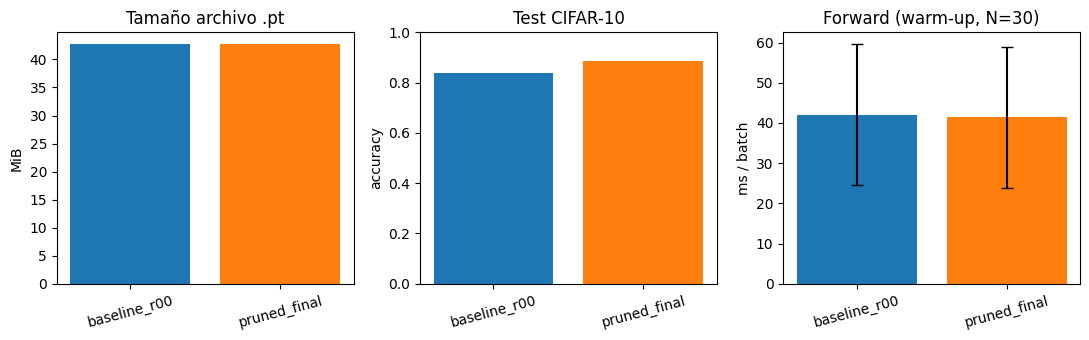

In [8]:
"""Gráficos de barras: disco, test acc, latencia."""

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
labels = df_cmp["modelo"].tolist()

axes[0].bar(labels, df_cmp["disco_MiB"], color=["C0", "C1"])
axes[0].set_ylabel("MiB")
axes[0].set_title("Tamaño archivo .pt")

axes[1].bar(labels, df_cmp["test_acc"], color=["C0", "C1"])
axes[1].set_ylabel("accuracy")
axes[1].set_title("Test CIFAR-10")
axes[1].set_ylim(0, 1)

axes[2].bar(labels, df_cmp["latency_mean_ms"], yerr=df_cmp["latency_std_ms"], color=["C0", "C1"], capsize=4)
axes[2].set_ylabel("ms / batch")
axes[2].set_title(f"Forward (warm-up, N={MAX_TIMING_BATCHES})")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

In [10]:
"""Recorte estructurado (columnas fc muertas + layer4 acotado): menos bytes en RAM.

Requiere las celdas de configuración e imports (`PRUNED_CKPT`, `REPO_ROOT`,
`load_state_dict`, `build_resnet_from_checkpoint`). Si IMP no dejó columnas
enteras nulas en `fc`, el slim coincide con el ancho original.
"""

from pia.pruning.resnet18_slim import (
    parameter_and_buffer_bytes,
    slim_resnet18_cifar_from_state_dict,
)

if not PRUNED_CKPT.is_file():
    raise FileNotFoundError(PRUNED_CKPT)

sd_pruned = load_state_dict(PRUNED_CKPT)
wide = build_resnet_from_checkpoint(sd_pruned)
b_wide = parameter_and_buffer_bytes(wide)
del wide

slim_model, slim_sd = slim_resnet18_cifar_from_state_dict(sd_pruned)
b_slim = parameter_and_buffer_bytes(slim_model)

print(f"PRUNED_CKPT: {PRUNED_CKPT}")
print(f"tensores (podado ancho): {b_wide / (1024**2):.4f} MiB")
print(f"tensores (slim):        {b_slim / (1024**2):.4f} MiB")
if b_slim < b_wide:
    print(f"ahorro: {(1 - b_slim / b_wide) * 100:.2f}% menos en parámetros+buffers")
else:
    print("(Sin columnas fc totalmente cero; slim = mismo ancho.)")

out_path = PRUNED_CKPT.parent / "model_slim_state.pt"
torch.save(slim_sd, out_path)
print(f"Guardado: {out_path.relative_to(REPO_ROOT)}")

PRUNED_CKPT: /Users/carlosvalerio/Documents/Study/Aprendizaje/pia/runs/lt/large-checkpoint/model_final.pt
tensores (podado ancho): 42.6621 MiB
tensores (slim):        42.6621 MiB
(Sin columnas fc totalmente cero; slim = mismo ancho.)
Guardado: runs/lt/large-checkpoint/model_slim_state.pt


In [9]:
"""Libera referencias y vacía caché del acelerador (opcional)."""

import gc

for _name in ("test_loader", "df_cmp", "df_logged", "results", "idx", "rounds"):
    if _name in globals():
        del globals()[_name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("Listo.")

Listo.
